This Jupyter Notebook is a demo of how the deepfakes that are generated from Generator blocks of GAN ensemble can be captured using very slight mismatched lighting conditions and color differences of 2 persons and also capture some dependencies locally or globally


In [2]:
# install dependencies


!pip install pywavelets matplotlib pillow numpy opencv-python tqdm

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
import cv2
import os
from tqdm import tqdm
from urllib.request import urlretrieve

In [10]:

# Load sample images directly from Colab storage
# (Assumes img2.png and img3.png are already uploaded to /content/)


import os
import shutil

os.makedirs("images/real", exist_ok=True)
os.makedirs("images/fake", exist_ok=True)

# Paths of your uploaded files
real_imgs_src = ["/content/img2.png"]
fake_imgs_src = ["/content/img3.png"]

# Copy them into the project folders
for i, src in enumerate(real_imgs_src):
    dst = os.path.join("images/real", f"img_{i}.jpg")
    shutil.copy(src, dst)

for i, src in enumerate(fake_imgs_src):
    dst = os.path.join("images/fake", f"img_{i}.jpg")
    shutil.copy(src, dst)

print("Images successfully copied from /content/ into dataset folders.")


Images successfully copied from /content/ into dataset folders.


In [11]:
# compute 2D FFT magnitude spectrum in log scale

def compute_fast_fourier_transform(images):
  gray = cv2.cvtColor(images, cv2.COLOR_BGR2GRAY)
  f = np.fft.fft2(gray)
  fshift = np.fft.fftshift(f)
  magnitude_spectrum = 20 * np.log(np.abs(fshift)+1)
  magnitude_norm = cv2.normalize(magnitude_spectrum,None,0,255,cv2.NORM_MINMAX)

  return magnitude_norm.astype(np.uint8)

In [12]:
# compute Discrete Wavelet Transform subbands (LL, LH, HL, HH)

def compute_wavelet(img,wavelet='db2',level=1):
  gray = cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
  coeffs2 = pywt.dwt2(gray,wavelet)
  LL,(LH,HL,HH) = coeffs2
  return LL,LH,HL,HH

In [13]:
# visualization helper

def show_wavelet_subbands(LL, LH, HL, HH):
  fig, axes = plt.subplots(1, 4, figsize=(12, 3))
  titles = ['LL (Approximation)', 'LH (Vertical Detail)', 'HL (Horizontal Detail)', 'HH (Diagonal Detail)']
  for ax, img, title in zip(axes, [LL, LH, HL, HH], titles):
    ax.imshow(np.abs(img), cmap='gray')
    ax.set_title(title)
    ax.axis('off')
  plt.show()

In [14]:
# Visualization of sample images (RGB, FFT, Wavelet)

def visualize_image_transforms(img_path, title_prefix=""):
  img = cv2.imread(img_path)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  # fast fourier transform
  fft_mag = compute_fast_fourier_transform(img)

  # Wavelet
  LL, LH, HL, HH = compute_wavelet(img)

  # plot results
  fig, axs = plt.subplots(1, 2, figsize=(10, 4))
  axs[0].imshow(img)
  axs[0].set_title(f"{title_prefix} - Original (RGB)")
  axs[0].axis('off')

  axs[1].imshow(fft_mag, cmap='inferno')
  axs[1].set_title(f"{title_prefix} - FFT Magnitude Spectrum")
  axs[1].axis('off')
  plt.show()

  print(f"Wavelet decomposition ({title_prefix}):")
  show_wavelet_subbands(LL, LH, HL, HH)

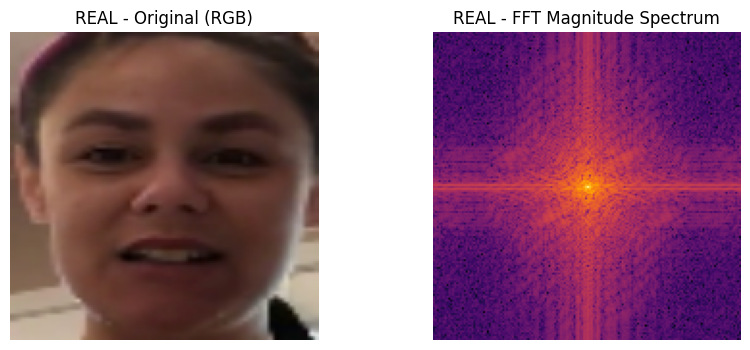

Wavelet decomposition (REAL):


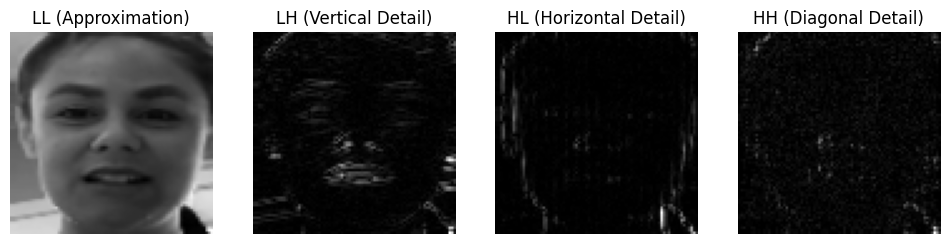

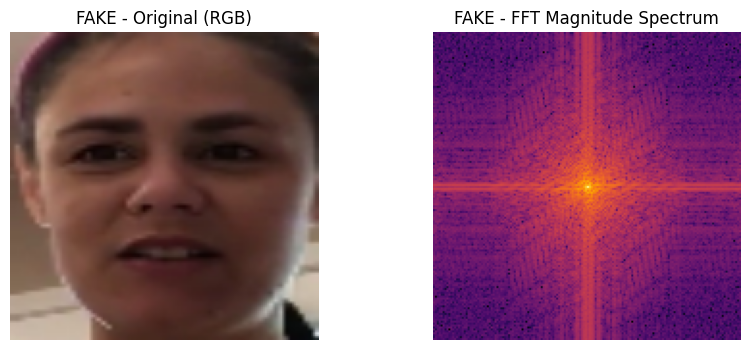

Wavelet decomposition (FAKE):


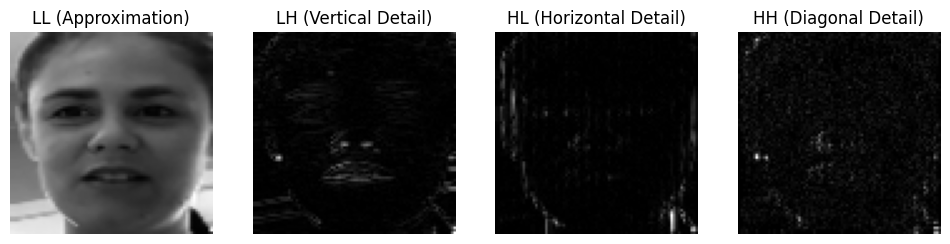

In [15]:
# run the visualization for real and fake images


real_imgs = sorted(os.listdir("images/real"))
fake_imgs = sorted(os.listdir("images/fake"))

for img in real_imgs:
    visualize_image_transforms(os.path.join("images/real", img), title_prefix="REAL")

for img in fake_imgs:
    visualize_image_transforms(os.path.join("images/fake", img), title_prefix="FAKE")